In [1]:
# Añade esto AL PRINCIPIO del notebook
import os
os.environ['TF_FORCE_GPU_ALLOW_GROWTH'] = 'true'  # Si usas TensorFlow
import gc
gc.collect()

# Verificar RAM disponible
!free -h

               total        used        free      shared  buff/cache   available
Mem:            12Gi       1.1Gi       8.4Gi       2.0Mi       3.2Gi        11Gi
Swap:             0B          0B          0B


In [2]:
import os
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter, defaultdict
from tqdm import tqdm

# Para cargar desde Kaggle Hub
import kagglehub

# Visión por computadora
import cv2
from PIL import Image

!pip install psutil
import psutil

# Detección de rostros y manos
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings('ignore')

In [3]:
print("\n[PASO 1] Descargando dataset desde Kaggle Hub...")
print("-" * 80)

try:
    # Descargar usando kagglehub
    path = kagglehub.dataset_download("kmader/food41")
    print(f"✅ Dataset descargado en: {path}")
    DATASET_DIR = path
except Exception as e:
    print(f"⚠️  Error al descargar: {e}")
    print("💡 Asegúrate de tener credenciales de Kaggle configuradas")
    print("   Tutorial: https://github.com/Kaggle/kagglehub")


[PASO 1] Descargando dataset desde Kaggle Hub...
--------------------------------------------------------------------------------
Using Colab cache for faster access to the 'food41' dataset.
✅ Dataset descargado en: /kaggle/input/food41


In [4]:
# ============================================================================
# PARTE 2: EXPLORACIÓN INICIAL DEL DATASET
# ============================================================================

print("\n[PASO 2] Exploración inicial del dataset...")
print("-" * 80)

# Definir las clases correspondientes al grupo desayuno
DESAYUNO_CLASSES = [
    'apple_pie', 'beignets', 'bread_pudding', 'breakfast_burrito',
    'cannoli', 'carrot_cake', 'cheesecake', 'chocolate_cake', 'churros', 'club_sandwich',
    'croque_madame', 'cup_cakes', 'donuts', 'eggs_benedict',
    'french_toast', 'grilled_cheese_sandwich', 'huevos_rancheros', 'omelette', 'pancakes',
    'strawberry_shortcake', 'waffles'
]

# Encontrar carpeta de imágenes
images_path = os.path.join(DATASET_DIR, "images")
if not os.path.exists(images_path):
    images_path = DATASET_DIR

print(f"📂 Ruta imágenes: {images_path}")

# Listar todas las clases que están en la carpeta (categorías de comida)
all_classes = sorted([d for d in os.listdir(images_path)
                 if os.path.isdir(os.path.join(images_path, d))])

# Filtrar solo las clases de desayuno
classes = [c for c in all_classes if c in DESAYUNO_CLASSES]

num_classes = len(classes)
print(f"📊 Número de clases de desayuno: {num_classes}")
print(f"🍲 Todas las clases de desayuno: {classes}")

# Contar imágenes por clase (para las clases de desayuno)
images_per_class = {}
total_images = 0

print("\n📈 Contando imágenes por clase...")
for class_name in tqdm(classes):
    class_path = os.path.join(images_path, class_name)
    num_images = len([f for f in os.listdir(class_path)
                      if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
    images_per_class[class_name] = num_images
    total_images += num_images

print(f"✅ Total de imágenes: {total_images}")



[PASO 2] Exploración inicial del dataset...
--------------------------------------------------------------------------------
📂 Ruta imágenes: /kaggle/input/food41/images
📊 Número de clases de desayuno: 21
🍲 Todas las clases de desayuno: ['apple_pie', 'beignets', 'bread_pudding', 'breakfast_burrito', 'cannoli', 'carrot_cake', 'cheesecake', 'chocolate_cake', 'churros', 'club_sandwich', 'croque_madame', 'cup_cakes', 'donuts', 'eggs_benedict', 'french_toast', 'grilled_cheese_sandwich', 'huevos_rancheros', 'omelette', 'pancakes', 'strawberry_shortcake', 'waffles']

📈 Contando imágenes por clase...


100%|██████████| 21/21 [00:00<00:00, 62.21it/s]

✅ Total de imágenes: 21000


In [5]:
# ============================================================================
# PARTE 3: ANÁLISIS DESCRIPTIVO DEL DATASET
# ============================================================================

print("\n[PASO 3] Análisis descriptivo...")
print("-" * 80)

# Filtrar images_per_class para incluir solo clases de desayuno
images_per_class = {k: v for k, v in images_per_class.items() if k in DESAYUNO_CLASSES}

# Crear DataFrame solo con clases desayuno
df_classes = pd.DataFrame({
    'clase': list(images_per_class.keys()),
    'num_imagenes': list(images_per_class.values())
})

print("\n📋 Estadísticas por clase:")
print(df_classes.describe())

print(f"\n🔍 Imágenes por clase:")
print(f"   Min: {df_classes['num_imagenes'].min()}")
print(f"   Max: {df_classes['num_imagenes'].max()}")
print(f"   Media: {df_classes['num_imagenes'].mean():.1f}")
print(f"   Std: {df_classes['num_imagenes'].std():.1f}")

# Top 10 clases con más imágenes (de desayuno)
top_10 = df_classes.nlargest(10, 'num_imagenes')
print(f"\n🏆 Top 10 clases con más imágenes:")
for idx, row in top_10.iterrows():
    print(f"   {row['clase']}: {row['num_imagenes']} imágenes")



[PASO 3] Análisis descriptivo...
--------------------------------------------------------------------------------

📋 Estadísticas por clase:
       num_imagenes
count          21.0
mean         1000.0
std             0.0
min          1000.0
25%          1000.0
50%          1000.0
75%          1000.0
max          1000.0

🔍 Imágenes por clase:
   Min: 1000
   Max: 1000
   Media: 1000.0
   Std: 0.0

🏆 Top 10 clases con más imágenes:
   apple_pie: 1000 imágenes
   beignets: 1000 imágenes
   bread_pudding: 1000 imágenes
   breakfast_burrito: 1000 imágenes
   cannoli: 1000 imágenes
   carrot_cake: 1000 imágenes
   cheesecake: 1000 imágenes
   chocolate_cake: 1000 imágenes
   churros: 1000 imágenes
   club_sandwich: 1000 imágenes


In [6]:
# ============================================================================
# PARTE 4: EXPLORACIÓN DE CARACTERÍSTICAS DE IMÁGENES
# ============================================================================

print("\n[PASO 4] Explorando características de imágenes...")
print("-" * 80)

# Muestrear imágenes para análisis de características
image_features = []
sample_size = 500  # Muestrear 500 imágenes para no tardar

print(f"🔍 Analizando {sample_size} imágenes para características...")

np.random.seed(42)
classes_sample = np.random.choice(classes, size=min(20, len(classes)), replace=False)

for class_name in tqdm(classes_sample):
    class_path = os.path.join(images_path, class_name)
    images = [f for f in os.listdir(class_path)
              if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    # Muestrear hasta 25 imágenes por clase
    for img_name in images[:25]:
        img_path = os.path.join(class_path, img_name)
        try:
            img = Image.open(img_path)
            width, height = img.size

            image_features.append({
                'clase': class_name,
                'width': width,
                'height': height,
                'aspect_ratio': width / height if height > 0 else 0,
                'mode': img.mode,
                'file_size_kb': os.path.getsize(img_path) / 1024
            })
        except Exception as e:
            print(f"   ⚠️  Error cargando {img_name}: {e}")

df_img_features = pd.DataFrame(image_features)

print(f"\n✅ Imágenes analizadas: {len(df_img_features)}")
print(f"\n📐 Dimensiones de imágenes:")
print(f"   Width - Min: {df_img_features['width'].min()}, "
      f"Max: {df_img_features['width'].max()}, "
      f"Media: {df_img_features['width'].mean():.0f}")
print(f"   Height - Min: {df_img_features['height'].min()}, "
      f"Max: {df_img_features['height'].max()}, "
      f"Media: {df_img_features['height'].mean():.0f}")

print(f"\n🎨 Modos de color:")
print(df_img_features['mode'].value_counts())

print(f"\n💾 Tamaño de archivos:")
print(f"   Min: {df_img_features['file_size_kb'].min():.1f} KB")
print(f"   Max: {df_img_features['file_size_kb'].max():.1f} KB")
print(f"   Media: {df_img_features['file_size_kb'].mean():.1f} KB")



[PASO 4] Explorando características de imágenes...
--------------------------------------------------------------------------------
🔍 Analizando 500 imágenes para características...


100%|██████████| 20/20 [00:03<00:00,  5.51it/s]



✅ Imágenes analizadas: 500

📐 Dimensiones de imágenes:
   Width - Min: 288, Max: 512, Media: 496
   Height - Min: 260, Max: 512, Media: 473

🎨 Modos de color:
mode
RGB    500
Name: count, dtype: int64

💾 Tamaño de archivos:
   Min: 21.3 KB
   Max: 176.0 KB
   Media: 49.2 KB


In [7]:
import os
import shutil
from tqdm import tqdm
import hashlib

# PARTE 4.5: COPIAR IMÁGENES Y ELIMINAR DUPLICADOS
print("\n[PARTE 4.5] Copiando imágenes de clases seleccionadas y eliminando duplicados...")
print("-" * 80)

# Configuración
INPUT_DIR = images_path  # ✅ USA LA RUTA DEL PASO 2 (de Kaggle Hub)
OUTPUT_DIR = '/content/images_clean'  # ✅ Cambio a /content
os.makedirs(OUTPUT_DIR, exist_ok=True)

classes = [
    'apple_pie', 'beignets', 'bread_pudding', 'breakfast_burrito',
    'cannoli', 'carrot_cake', 'cheesecake', 'chocolate_cake', 'churros', 'club_sandwich',
    'croque_madame', 'cup_cakes', 'donuts', 'eggs_benedict',
    'french_toast', 'grilled_cheese_sandwich', 'huevos_rancheros', 'omelette', 'pancakes',
    'strawberry_shortcake', 'waffles'
]

# Verificar si el directorio de entrada existe
if not os.path.exists(INPUT_DIR):
    print(f"❌ ERROR: El directorio {INPUT_DIR} no existe")
    print("💡 Descarga el dataset Food-101 con:")
    print("   !wget http://data.vision.ee.ethz.ch/cvl/food-101.tar.gz -O /content/food-101.tar.gz")
    print("   !tar -xzf /content/food-101.tar.gz -C /content")
    raise FileNotFoundError(f"Directorio {INPUT_DIR} no encontrado")

# Diccionario para almacenar imágenes duplicadas
duplicates_list = {}
total_images = 0
duplicates_count = 0

# Función para calcular hash de una imagen
def calculate_hash(image_path):
    try:
        with open(image_path, 'rb') as f:
            return hashlib.md5(f.read()).hexdigest()
    except Exception as e:
        print(f"⚠️ Error al calcular hash de {image_path}: {e}")
        return None

# Copiar imágenes y detectar duplicados
for cls in tqdm(classes, desc="Clases desayuno"):
    src_dir = os.path.join(INPUT_DIR, cls)
    dst_dir = os.path.join(OUTPUT_DIR, cls)
    os.makedirs(dst_dir, exist_ok=True)

    if not os.path.exists(src_dir):
        print(f"❌ Carpeta {src_dir} no existe")
        duplicates_list[cls] = []
        continue

    image_hashes = {}
    duplicates_list[cls] = []

    for img_name in os.listdir(src_dir):
        if not img_name.endswith('.jpg'):
            continue
        src_path = os.path.join(src_dir, img_name)
        img_hash = calculate_hash(src_path)

        if img_hash is None:
            continue

        if img_hash in image_hashes:
            duplicates_list[cls].append(img_name)
            duplicates_count += 1
            continue

        image_hashes[img_hash] = img_name
        dst_path = os.path.join(dst_dir, img_name)
        try:
            shutil.copy(src_path, dst_path)
            total_images += 1
        except Exception as e:
            print(f"⚠️ Error al copiar {src_path}: {e}")
            continue

    print(f"{cls}: {len(image_hashes)} imágenes copiadas, {len(duplicates_list[cls])} duplicadas")

print(f"\n✅ Total imágenes copiadas: {total_images}")
print(f"📊 Total imágenes duplicadas: {duplicates_count}")
print(f"📂 duplicates_list generado con {len(duplicates_list)} clases")


[PARTE 4.5] Copiando imágenes de clases seleccionadas y eliminando duplicados...
--------------------------------------------------------------------------------


Clases desayuno:   5%|▍         | 1/21 [00:09<03:08,  9.43s/it]

apple_pie: 1000 imágenes copiadas, 0 duplicadas


Clases desayuno:  10%|▉         | 2/21 [00:17<02:43,  8.58s/it]

beignets: 1000 imágenes copiadas, 0 duplicadas


...

pancakes: 1000 imágenes copiadas, 0 duplicadas


Clases desayuno:  95%|█████████▌| 20/21 [02:47<00:08,  8.66s/it]

strawberry_shortcake: 1000 imágenes copiadas, 0 duplicadas


Clases desayuno: 100%|██████████| 21/21 [02:56<00:00,  8.40s/it]

waffles: 1000 imágenes copiadas, 0 duplicadas

✅ Total imágenes copiadas: 20999
📊 Total imágenes duplicadas: 1
📂 duplicates_list generado con 21 clases


In [8]:
# PARTE 5 ULTRA-MEJORADA: DETECCIÓN REALISTA DE IMÁGENES RUIDOSAS (SIN DUPLICADOS)
print("\n[PASO 5] Detección de imágenes ruidosas (ULTRA-REALISTA, sin duplicados)...")
print("-" * 80)

from PIL import Image, ImageStat, ImageFilter
from scipy import ndimage
import numpy as np
import pandas as pd
import os
from tqdm import tqdm

class ImageQualityChecker:
    def __init__(self):
        pass

    def detect_human_skin(self, img_path):
        try:
            img = Image.open(img_path).convert('RGB')
            img_array = np.array(img)
            r = img_array[:, :, 0].astype(float)
            g = img_array[:, :, 1].astype(float)
            b = img_array[:, :, 2].astype(float)
            rgb_cond = (
                (r > 95) & (r < 255) &
                (g > 40) & (g < 220) &
                (b > 20) & (b < 200) &
                (r > g) & (g > b)
            )
            diff_rg = r - g
            diff_rb = r - b
            diff_cond = (diff_rg > 15) & (diff_rb > 15) & (diff_rg < 80)
            with np.errstate(divide='ignore', invalid='ignore'):
                ratio_rg = r / (g + 1)
                ratio_rb = r / (b + 1)
                ratio_cond = (ratio_rg > 1.0) & (ratio_rg < 2.5) & (ratio_rb > 1.0) & (ratio_rb < 3.0)
            hsv_img = img.convert('HSV')
            hsv_array = np.array(hsv_img)
            saturation = hsv_array[:, :, 1]
            sat_cond = (saturation > 20) & (saturation < 150)
            skin_mask = rgb_cond & diff_cond & ratio_cond & sat_cond
            total_pixels = img_array.shape[0] * img_array.shape[1]
            skin_pixels = np.count_nonzero(skin_mask)
            skin_percentage = (skin_pixels / total_pixels) * 100
            has_suspicious_skin = skin_percentage > 40
            return has_suspicious_skin, skin_percentage
        except Exception as e:
            return False, 0.0

    def detect_face_structure(self, img_path):
        try:
            img = Image.open(img_path).convert('L')
            img_small = img.resize((100, 100))
            img_array = np.array(img_small)
            from scipy.ndimage import sobel
            sx = sobel(img_array, axis=0, mode='constant')
            sy = sobel(img_array, axis=1, mode='constant')
            sobel_img = np.hypot(sx, sy)
            h, w = sobel_img.shape
            grid_h, grid_w = h // 3, w // 3
            oval_scores = []
            for i in range(3):
                for j in range(3):
                    region = sobel_img[i*grid_h:(i+1)*grid_h, j*grid_w:(j+1)*grid_w]
                    center_mass = np.mean(region)
                    edge_variance = np.std(region)
                    oval_score = edge_variance / (center_mass + 1)
                    oval_scores.append(oval_score)
            max_oval_score = max(oval_scores)
            has_face_structure = max_oval_score > 2.0
            return has_face_structure, max_oval_score
        except Exception as e:
            return False, 0.0

    def detect_symmetry(self, img_path):
        try:
            img = Image.open(img_path).convert('L')
            img_small = img.resize((100, 100))
            img_array = np.array(img_small)
            mid = img_array.shape[1] // 2
            left_half = img_array[:, :mid]
            right_half = np.fliplr(img_array[:, mid:])
            min_width = min(left_half.shape[1], right_half.shape[1])
            left_half = left_half[:, :min_width]
            right_half = right_half[:, :min_width]
            diff = np.abs(left_half.astype(float) - right_half.astype(float))
            similarity = 1 - (np.mean(diff) / 255.0)
            is_symmetric = similarity > 0.75
            return is_symmetric, similarity
        except Exception as e:
            return False, 0.0

    def detect_hands_realistic(self, img_path):
        try:
            img = Image.open(img_path).convert('RGB')
            img_array = np.array(img)
            h, w = img_array.shape[:2]
            border_width = int(w * 0.2)
            border_height = int(h * 0.2)
            top_border = img_array[:border_height, :]
            bottom_border = img_array[-border_height:, :]
            left_border = img_array[:, :border_width]
            right_border = img_array[:, -border_width:]
            borders = [top_border, bottom_border, left_border, right_border]
            skin_in_borders = []
            for border in borders:
                r = border[:, :, 0].astype(float)
                g = border[:, :, 1].astype(float)
                b = border[:, :, 2].astype(float)
                skin_cond = (
                    (r > 95) & (g > 40) & (b > 20) &
                    (r > g) & (g > b) & ((r - g) > 15)
                )
                skin_pct = np.count_nonzero(skin_cond) / border.size * 100
                skin_in_borders.append(skin_pct)
            max_skin_border = max(skin_in_borders)
            has_hands = max_skin_border > 30
            return has_hands, max_skin_border
        except Exception as e:
            return False, 0.0

    def check_image_sharpness(self, img_path):
        try:
            img = Image.open(img_path).convert('L')
            img_array = np.array(img)
            from scipy.ndimage import sobel
            sx = sobel(img_array, axis=0)
            sy = sobel(img_array, axis=1)
            gradient_magnitude = np.hypot(sx, sy)
            sharpness = np.var(gradient_magnitude)
            is_sharp = sharpness > 50
            return is_sharp, sharpness
        except Exception as e:
            return True, 0.0

    def check_brightness_contrast(self, img_path):
        try:
            img = Image.open(img_path).convert('L')
            stat = ImageStat.Stat(img)
            brightness = stat.mean[0]
            contrast = stat.stddev[0]
            is_bright = 30 < brightness < 230
            is_contrast = contrast > 20
            return (is_bright and is_contrast), brightness, contrast
        except Exception as e:
            return True, 0.0, 0.0

    def check_food_characteristics(self, img_path):
        try:
            img = Image.open(img_path).convert('RGB')
            img_small = img.resize((50, 50))
            pixels = list(img_small.getdata())
            colors_red = [p[0] for p in pixels]
            colors_green = [p[1] for p in pixels]
            colors_blue = [p[2] for p in pixels]
            std_r = np.std(colors_red)
            std_g = np.std(colors_green)
            std_b = np.std(colors_blue)
            color_variance = (std_r + std_g + std_b) / 3
            mean_r = np.mean(colors_red)
            mean_g = np.mean(colors_green)
            mean_b = np.mean(colors_blue)
            is_warm = mean_r > mean_b
            has_variance = color_variance > 30
            is_food_like = is_warm and has_variance
            return is_food_like, color_variance
        except Exception as e:
            return True, 0.0

    def analyze_image(self, img_path):
        try:
            has_skin, skin_pct = self.detect_human_skin(img_path)
            has_face_struct, face_score = self.detect_face_structure(img_path)
            is_symmetric, symmetry_score = self.detect_symmetry(img_path)
            has_hands, hands_score = self.detect_hands_realistic(img_path)
            is_food, food_score = self.check_food_characteristics(img_path)
            is_sharp, sharpness = self.check_image_sharpness(img_path)
            is_quality_bc, brightness, contrast = self.check_brightness_contrast(img_path)
            has_face = (has_face_struct and is_symmetric and has_skin)
            has_obvious_person = has_face or (has_hands and skin_pct > 35)
            not_food_with_skin = (not is_food and has_skin)
            is_problematic = (
                has_obvious_person or
                not_food_with_skin or
                (not is_sharp and skin_pct > 50)
            )
            return {
                'tiene_rostro': has_face,
                'face_structure_score': face_score,
                'symmetry_score': symmetry_score,
                'tiene_manos_obvias': has_hands,
                'hands_score': hands_score,
                'porcentaje_piel': skin_pct,
                'es_comida': is_food,
                'food_score': food_score,
                'es_nitida': is_sharp,
                'sharpness_score': sharpness,
                'buen_brillo_contraste': is_quality_bc,
                'brightness': brightness,
                'contrast': contrast,
                'es_problematica': is_problematic
            }
        except Exception as e:
            print(f"   Error: {e}")
            return None

# EJECUTAR ANÁLISIS
print("🔎 Analizando calidad con criterios ULTRA-REALISTAS...")
try:
    from scipy import ndimage
    from scipy.ndimage import sobel
    has_scipy = True
except ImportError:
    print("⚠️ scipy no disponible, usando métodos alternativos...")
    has_scipy = False

checker = ImageQualityChecker()
quality_results = []
working_path = '/content/images_clean'  # ✅ CAMBIO: añadido /images_clean
sample_images = 300
img_count = 0

print(f"\nAnalizando {sample_images} imágenes (sin duplicados)...")
classes = ['apple_pie', 'beignets', 'bread_pudding', 'breakfast_burrito',
           'cannoli', 'carrot_cake', 'cheesecake', 'chocolate_cake', 'churros', 'club_sandwich',
           'croque_madame', 'cup_cakes', 'donuts', 'eggs_benedict',
           'french_toast', 'grilled_cheese_sandwich', 'huevos_rancheros', 'omelette', 'pancakes',
           'strawberry_shortcake', 'waffles']

for class_name in tqdm(classes, desc="Clases desayuno"):
    class_path = os.path.join(working_path, class_name)
    if not os.path.exists(class_path):
        print(f"{class_name}: no existe")
        continue
    images = [f for f in os.listdir(class_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    images = [f for f in images if f not in duplicates_list.get(class_name, [])]
    images.sort()
    for img_name in images[:20]:
        if img_count >= sample_images:
            break
        img_path = os.path.join(class_path, img_name)
        result = checker.analyze_image(img_path)
        if result:
            result['clase'] = class_name
            result['imagen'] = img_name
            quality_results.append(result)
            img_count += 1
    if img_count >= sample_images:
        break

df_quality = pd.DataFrame(quality_results)

# ESTADÍSTICAS REALISTAS
print(f"\n✅ Imágenes analizadas: {len(df_quality)}")
if len(df_quality) > 0:
    print(f"\n⚠️ Problemas detectados (CRITERIOS ESTRICTOS):")
    num_faces = df_quality['tiene_rostro'].sum()
    pct_faces = 100 * num_faces / len(df_quality)
    print(f"   👤 Rostros humanos detectados: {num_faces} ({pct_faces:.1f}%)")
    num_hands = df_quality['tiene_manos_obvias'].sum()
    pct_hands = 100 * num_hands / len(df_quality)
    print(f"   ✋ Manos sosteniendo comida: {num_hands} ({pct_hands:.1f}%)")
    num_not_food = (~df_quality['es_comida']).sum()
    pct_not_food = 100 * num_not_food / len(df_quality)
    print(f"   🚫 NO parece comida: {num_not_food} ({pct_not_food:.1f}%)")
    num_blurry = (~df_quality['es_nitida']).sum()
    pct_blurry = 100 * num_blurry / len(df_quality)
    print(f"   📷 Imágenes muy borrosas: {num_blurry} ({pct_blurry:.1f}%)")
    num_bad_light = (~df_quality['buen_brillo_contraste']).sum()
    pct_bad_light = 100 * num_bad_light / len(df_quality)
    print(f"   💡 Iluminación extrema: {num_bad_light} ({pct_bad_light:.1f}%)")
    problematic_images = df_quality['es_problematica'].sum()
    pct_problematic = 100 * problematic_images / len(df_quality)
    print(f"\n   ❌ TOTAL PROBLEMÁTICAS: {problematic_images} ({pct_problematic:.1f}%)")
    print(f"\n📊 Estadísticas promedio:")
    print(f"   Porcentaje piel detectado: {df_quality['porcentaje_piel'].mean():.1f}%")
    print(f"   Score de estructura facial: {df_quality['face_structure_score'].mean():.3f}")
    print(f"   Score de simetría: {df_quality['symmetry_score'].mean():.3f}")
    print(f"   Nitidez: {df_quality['sharpness_score'].mean():.1f}")
    problematic_df = df_quality[df_quality['es_problematica']]
    if len(problematic_df) > 0:
        print(f"\n🔍 Ejemplos de imágenes REALMENTE problemáticas:")
        for idx, row in problematic_df.head(5).iterrows():
            reasons = []
            if row['tiene_rostro']:
                reasons.append(f"ROSTRO HUMANO (simetría: {row['symmetry_score']:.2f})")
            if row['tiene_manos_obvias']:
                reasons.append(f"MANOS en bordes ({row['hands_score']:.1f}%)")
            if not row['es_comida']:
                reasons.append("NO es comida")
            if not row['es_nitida'] and row['porcentaje_piel'] > 50:
                reasons.append("Borrosa con mucha piel")
            print(f"   • {row['clase']}/{row['imagen']}")
            print(f"     Razones: {', '.join(reasons)}")
            print(f"     Piel: {row['porcentaje_piel']:.1f}%")
    else:
        print(f"\n✅ ¡Excelente! No se detectaron imágenes problemáticas")
        print(f"   El dataset parece limpio y enfocado en comida")
else:
    print("⚠️ No se pudo analizar ninguna imagen")


[PASO 5] Detección de imágenes ruidosas (ULTRA-REALISTA, sin duplicados)...
--------------------------------------------------------------------------------
🔎 Analizando calidad con criterios ULTRA-REALISTAS...

Analizando 300 imágenes (sin duplicados)...


Clases desayuno:  67%|██████▋   | 14/21 [00:17<00:08,  1.22s/it]


✅ Imágenes analizadas: 300

⚠️ Problemas detectados (CRITERIOS ESTRICTOS):
   👤 Rostros humanos detectados: 18 (6.0%)
   ✋ Manos sosteniendo comida: 8 (2.7%)
   🚫 NO parece comida: 20 (6.7%)
   📷 Imágenes muy borrosas: 0 (0.0%)
   💡 Iluminación extrema: 0 (0.0%)

   ❌ TOTAL PROBLEMÁTICAS: 19 (6.3%)

📊 Estadísticas promedio:
   Porcentaje piel detectado: 16.6%
   Score de estructura facial: inf
   Score de simetría: 0.794
   Nitidez: inf

🔍 Ejemplos de imágenes REALMENTE problemáticas:
   • apple_pie/101251.jpg
     Razones: ROSTRO HUMANO (simetría: 0.90), NO es comida
     Piel: 54.5%
   • apple_pie/1074942.jpg
     Razones: ROSTRO HUMANO (simetría: 0.92), NO es comida
     Piel: 49.0%
   • beignets/1034417.jpg
     Razones: ROSTRO HUMANO (simetría: 0.79), MANOS en bordes (31.0%)
     Piel: 74.8%
   • beignets/1036242.jpg
     Razones: ROSTRO HUMANO (simetría: 0.86)
     Piel: 61.9%
   • beignets/1048606.jpg
     Razones: ROSTRO HUMANO (simetría: 0.84)
     Piel: 48.0%



[PASO 6] Generando visualizaciones para clases de desayuno (sin duplicados)...
--------------------------------------------------------------------------------
⚠️ df_img_features no disponible o no tiene columna 'imagen'


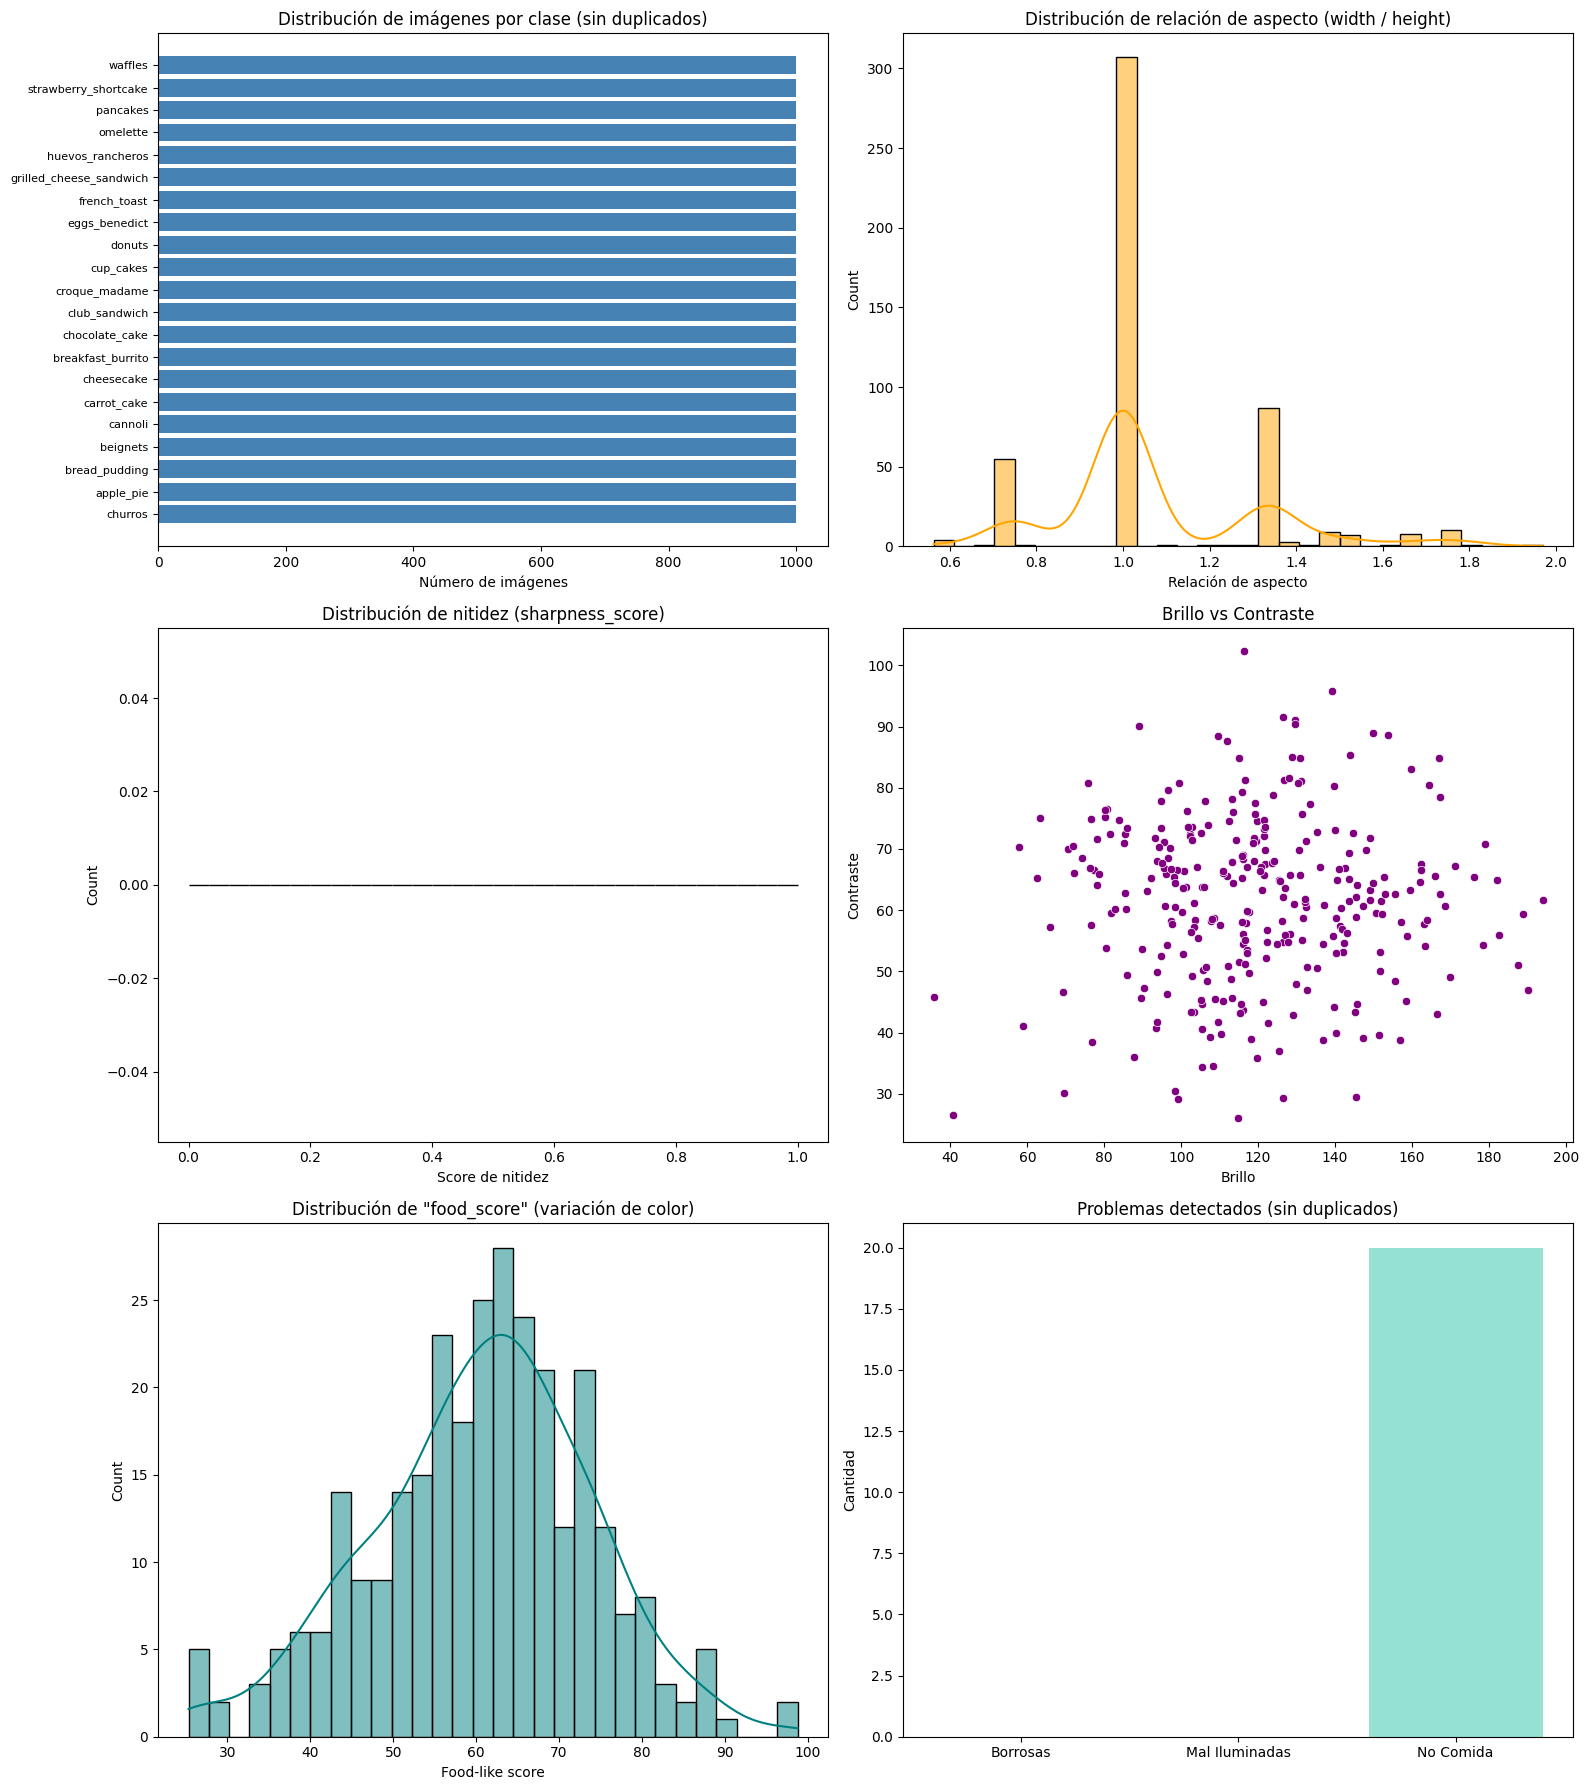

In [9]:
# PARTE 6: VISUALIZACIONES (SIN IMÁGENES DUPLICADAS)
print("\n[PASO 6] Generando visualizaciones para clases de desayuno (sin duplicados)...")
print("-" * 80)

# %matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import os

# Asegurar lista de clases desayuno
classes = [
    'apple_pie', 'beignets', 'bread_pudding', 'breakfast_burrito',
    'cannoli', 'carrot_cake', 'cheesecake', 'chocolate_cake', 'churros', 'club_sandwich',
    'croque_madame', 'cup_cakes', 'donuts', 'eggs_benedict',
    'french_toast', 'grilled_cheese_sandwich', 'huevos_rancheros', 'omelette', 'pancakes',
    'strawberry_shortcake', 'waffles'
]

# Actualizar df_classes para contar solo imágenes no duplicadas
working_path = '/content/images_clean'
data = []
for class_name in classes:
    class_path = os.path.join(working_path, class_name)
    if os.path.exists(class_path):
        images = [f for f in os.listdir(class_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        images = [f for f in images if f not in duplicates_list.get(class_name, [])]
        data.append({'clase': class_name, 'num_imagenes': len(images)})
    else:
        data.append({'clase': class_name, 'num_imagenes': 0})
df_classes = pd.DataFrame(data)

# Filtrar df_img_features si existe y tiene la columna 'imagen'
if 'df_img_features' in globals() and len(df_img_features) > 0 and 'imagen' in df_img_features.columns:
    df_img_features_desayuno = df_img_features[df_img_features['clase'].isin(classes)].copy()
    df_img_features_desayuno = df_img_features_desayuno[
        ~df_img_features_desayuno.apply(lambda x: x['imagen'] in duplicates_list.get(x['clase'], []), axis=1)
    ]
else:
    df_img_features_desayuno = None
    print("⚠️ df_img_features no disponible o no tiene columna 'imagen'")

# Filtrar df_quality si existe y tiene la columna 'imagen'
if 'df_quality' in globals() and len(df_quality) > 0 and 'imagen' in df_quality.columns:
    df_quality_desayuno = df_quality[df_quality['clase'].isin(classes)].copy()
    df_quality_desayuno = df_quality_desayuno[
        ~df_quality_desayuno.apply(lambda x: x['imagen'] in duplicates_list.get(x['clase'], []), axis=1)
    ]
else:
    df_quality_desayuno = None
    print("⚠️ df_quality no disponible o no tiene columna 'imagen'")

# Crear figura con 3 filas y 2 columnas para varias visualizaciones
fig, axes = plt.subplots(3, 2, figsize=(16, 18))

# 1. Distribución de imágenes por clase (desayuno)
ax1 = axes[0, 0]
df_sorted = df_classes.sort_values('num_imagenes', ascending=True)
ax1.barh(df_sorted['clase'], df_sorted['num_imagenes'], color='steelblue')
ax1.set_xlabel('Número de imágenes')
ax1.set_title('Distribución de imágenes por clase (sin duplicados)')
ax1.tick_params(axis='y', labelsize=8)

# 2. Distribución de relación de aspecto
ax2 = axes[0, 1]
if df_img_features is not None and 'aspect_ratio' in df_img_features.columns:
    sns.histplot(df_img_features['aspect_ratio'], bins=30, ax=ax2, kde=True, color='orange')
    ax2.set_title('Distribución de relación de aspecto (width / height)')
    ax2.set_xlabel('Relación de aspecto')
else:
    ax2.text(0.5, 0.5, 'No hay datos de dimensiones', ha='center', va='center')
    ax2.set_title('Relación de aspecto')

# 3. Nitidez (sharpness_score)
ax3 = axes[1, 0]
if df_quality_desayuno is not None and 'sharpness_score' in df_quality_desayuno.columns:
    sns.histplot(df_quality_desayuno['sharpness_score'], bins=30, ax=ax3, color='green', kde=True)
    ax3.set_title('Distribución de nitidez (sharpness_score)')
    ax3.set_xlabel('Score de nitidez')
else:
    ax3.text(0.5, 0.5, 'No hay datos de nitidez', ha='center', va='center')

# 4. Brillo y contraste
ax4 = axes[1, 1]
if df_quality_desayuno is not None and all(c in df_quality_desayuno.columns for c in ['brightness', 'contrast']):
    sns.scatterplot(data=df_quality_desayuno, x='brightness', y='contrast', ax=ax4, color='purple')
    ax4.set_title('Brillo vs Contraste')
    ax4.set_xlabel('Brillo')
    ax4.set_ylabel('Contraste')
else:
    ax4.text(0.5, 0.5, 'No hay datos de brillo/contraste', ha='center', va='center')

# 5. Score de "es_comida" (food_score)
ax5 = axes[2, 0]
if df_quality_desayuno is not None and 'food_score' in df_quality_desayuno.columns:
    sns.histplot(df_quality_desayuno['food_score'], bins=30, ax=ax5, color='teal', kde=True)
    ax5.set_title('Distribución de "food_score" (variación de color)')
    ax5.set_xlabel('Food-like score')
else:
    ax5.text(0.5, 0.5, 'No hay datos de food_score', ha='center', va='center')

# 6. Comparativa de problemas de calidad
ax6 = axes[2, 1]
if df_quality_desayuno is not None and 'es_problematica' in df_quality_desayuno.columns:
    issues = {
        'Borrosas': (~df_quality_desayuno['es_nitida']).sum(),
        'Mal Iluminadas': (~df_quality_desayuno['buen_brillo_contraste']).sum(),
        'No Comida': (~df_quality_desayuno['es_comida']).sum(),
    }
    ax6.bar(issues.keys(), issues.values(), color=['#ff9a8b', '#4a90e2', '#95e1d3'])
    ax6.set_title('Problemas detectados (sin duplicados)')
    ax6.set_ylabel('Cantidad')
else:
    ax6.text(0.5, 0.5, 'No hay datos de calidad', ha='center', va='center')

plt.tight_layout()
plt.show()


In [10]:
# PARTE 7: PREPROCESAMIENTO DEL DATASET (SIN DUPLICADOS NI PROBLEMÁTICAS)
print("\n[PASO 7] Preprocesando imágenes de desayuno (sin duplicados ni problemáticas)...")
print("-" * 80)

import os
import numpy as np
import cv2
import pandas as pd

# Configuración
TARGET_SIZE = 224  # Tamaño de imagen
SAVE_DIR = '/content/desayuno_preprocessed'  # Directorio de salida
os.makedirs(SAVE_DIR, exist_ok=True)
classes = [
    'apple_pie', 'beignets', 'bread_pudding', 'breakfast_burrito',
    'cannoli', 'carrot_cake', 'cheesecake', 'chocolate_cake', 'churros', 'club_sandwich',
    'croque_madame', 'cup_cakes', 'donuts', 'eggs_benedict',
    'french_toast', 'grilled_cheese_sandwich', 'huevos_rancheros', 'omelette', 'pancakes',
    'strawberry_shortcake', 'waffles'
]

# Verificar existencia de la carpeta de imágenes
images_path = '/content/images_clean'
if not os.path.exists(images_path):
    print(f"❌ ERROR: La carpeta {images_path} no existe")
    print("💡 Verifica que la Parte 4.5 (eliminación de duplicados) se ejecutó correctamente")
    raise FileNotFoundError(f"Carpeta {images_path} no encontrada")

# Confirmar número de imágenes en images_clean
total_images_input = 0
for class_name in classes:
    class_path = os.path.join(images_path, class_name)
    if os.path.exists(class_path):
        num = len([f for f in os.listdir(class_path) if f.endswith(('.jpg', '.jpeg', '.png'))])
        total_images_input += num
        print(f"   {class_name}: {num} imágenes")
    else:
        print(f"   {class_name}: no existe")
print(f"📂 TOTAL en images_clean: {total_images_input} imágenes")

stats = {}
total_processed = 0
total_skipped = 0
npz_files_created = []  # Lista para rastrear archivos NPZ generados

for class_idx, class_name in enumerate(classes):
    class_path = os.path.join(images_path, class_name)
    if not os.path.exists(class_path):
        print(f"⚠️ {class_name} no existe en {images_path}")
        stats[class_name] = {'processed': 0, 'skipped': 0, 'rejections': {}}
        continue

    # Obtener imágenes no duplicadas
    images = [f for f in os.listdir(class_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    images = [f for f in images if f not in duplicates_list.get(class_name, [])]
    total_in_class = len(images)

    # Filtrar imágenes problemáticas usando df_quality
    problem_images = set()
    if 'df_quality' in globals() and len(df_quality) > 0 and 'imagen' in df_quality.columns:
        problem_images = set(df_quality[
            (df_quality['clase'] == class_name) & (df_quality['es_problematica'])
        ]['imagen'])

    X_buffer = []
    y_buffer = []
    processed = 0
    skipped = 0
    rejections = {}

    print(f"🔄 Procesando {class_name} ({total_in_class} imágenes)...")
    for img_name in images:
        if img_name in problem_images:
            skipped += 1
            rejections['Problemática (rostros/manos)'] = rejections.get('Problemática (rostros/manos)', 0) + 1
            continue

        img_path = os.path.join(class_path, img_name)
        img = cv2.imread(img_path)
        if img is None:
            print(f"⚠️ Error al leer {img_name} en {class_name}")
            skipped += 1
            rejections['Error lectura'] = rejections.get('Error lectura', 0) + 1
            continue

        # Redimensionar y normalizar
        try:
            img = cv2.resize(img, (TARGET_SIZE, TARGET_SIZE), interpolation=cv2.INTER_LANCZOS4)
            img_array = img.astype(np.float16) / 255.0
            X_buffer.append(img_array)
            y_buffer.append(class_idx)
            processed += 1
        except Exception as e:
            print(f"⚠️ Error procesando {img_name} en {class_name}: {e}")
            skipped += 1
            rejections['Error procesamiento'] = rejections.get('Error procesamiento', 0) + 1
            continue

        # Guardar cada 20 imágenes para evitar sobrecarga de memoria
        if len(X_buffer) >= 20:
            batch_number = processed // 20
            npz_filename = f'c{class_idx:03d}_batch{batch_number:04d}.npz'
            npz_path = os.path.join(SAVE_DIR, npz_filename)
            try:
                np.savez_compressed(
                    npz_path,
                    X=np.array(X_buffer, dtype=np.float16),
                    y=np.array(y_buffer, dtype=np.int16)
                )
                npz_files_created.append(npz_filename)
                print(f"✅ Guardado {npz_filename} ({len(X_buffer)} imágenes)")
            except Exception as e:
                print(f"❌ Error al guardar {npz_filename}: {e}")
            X_buffer.clear()
            y_buffer.clear()

    # Guardar imágenes restantes
    if X_buffer:
        batch_number = processed // 20
        npz_filename = f'c{class_idx:03d}_batch{batch_number:04d}.npz'
        npz_path = os.path.join(SAVE_DIR, npz_filename)
        try:
            np.savez_compressed(
                npz_path,
                X=np.array(X_buffer, dtype=np.float16),
                y=np.array(y_buffer, dtype=np.int16)
            )
            npz_files_created.append(npz_filename)
            print(f"✅ Guardado {npz_filename} ({len(X_buffer)} imágenes)")
        except Exception as e:
            print(f"❌ Error al guardar {npz_filename}: {e}")

    # Estadísticas
    acceptance = 100 * processed / total_in_class if total_in_class > 0 else 0
    print(f"✓ {class_name}: {processed}/{total_in_class} ({acceptance:.0f}%)")
    stats[class_name] = {'processed': processed, 'skipped': skipped, 'rejections': rejections}
    total_processed += processed
    total_skipped += skipped

# Guardar estadísticas
np.save(os.path.join(SAVE_DIR, 'stats.npy'), stats)
print(f"\n📊 Resumen total: {total_processed} aceptadas, {total_skipped} rechazadas")
print(f"📂 Archivos NPZ generados: {len(npz_files_created)}")

# Verificar archivos NPZ generados
print("\n📂 Verificando archivos NPZ en", SAVE_DIR)
npz_files = [f for f in os.listdir(SAVE_DIR) if f.endswith('.npz')]
for npz_file in npz_files:
    size_mb = os.path.getsize(os.path.join(SAVE_DIR, npz_file)) / (1024**2)
    print(f"   {npz_file}: {size_mb:.2f} MB")
print(f"   TOTAL: {len(npz_files)} archivos NPZ")


[PASO 7] Preprocesando imágenes de desayuno (sin duplicados ni problemáticas)...
--------------------------------------------------------------------------------
   apple_pie: 1000 imágenes
   beignets: 1000 imágenes
   bread_pudding: 1000 imágenes
   breakfast_burrito: 1000 imágenes
   cannoli: 1000 imágenes
   carrot_cake: 1000 imágenes
   cheesecake: 1000 imágenes
   chocolate_cake: 1000 imágenes
   churros: 999 imágenes
   club_sandwich: 1000 imágenes
   croque_madame: 1000 imágenes
   cup_cakes: 1000 imágenes
   donuts: 1000 imágenes
   eggs_benedict: 1000 imágenes
   french_toast: 1000 imágenes
   grilled_cheese_sandwich: 1000 imágenes
   huevos_rancheros: 1000 imágenes
   omelette: 1000 imágenes
   pancakes: 1000 imágenes
   strawberry_shortcake: 1000 imágenes
   waffles: 1000 imágenes
📂 TOTAL en images_clean: 20999 imágenes
🔄 Procesando apple_pie (1000 imágenes)...
✅ Guardado c000_batch0001.npz (20 imágenes)
✅ Guardado c000_batch0002.npz (20 imágenes)
✅ Guardado c000_batch0003


[PASO 8] Estadísticas finales y visualizaciones (sin duplicados ni problemáticas)...
--------------------------------------------------------------------------------

📊 Resumen final:
   total_clases: 21
   total_imagenes: 20980
   clase_min_imagenes: 996
   clase_max_imagenes: 1000
   clase_media_imagenes: 999.047619047619
   imágenes_problemáticas: 19
   imágenes_duplicadas: 1
   target_size: 48

🏷️ Distribución de clases:
   apple_pie: 998 imágenes
   beignets: 997 imágenes
   bread_pudding: 996 imágenes
   breakfast_burrito: 999 imágenes
   cannoli: 998 imágenes
   carrot_cake: 998 imágenes
   cheesecake: 998 imágenes
   chocolate_cake: 1000 imágenes
   churros: 999 imágenes
   club_sandwich: 999 imágenes
   croque_madame: 999 imágenes
   cup_cakes: 999 imágenes
   donuts: 1000 imágenes
   eggs_benedict: 1000 imágenes
   french_toast: 1000 imágenes
   grilled_cheese_sandwich: 1000 imágenes
   huevos_rancheros: 1000 imágenes
   omelette: 1000 imágenes
   pancakes: 1000 imágenes
   

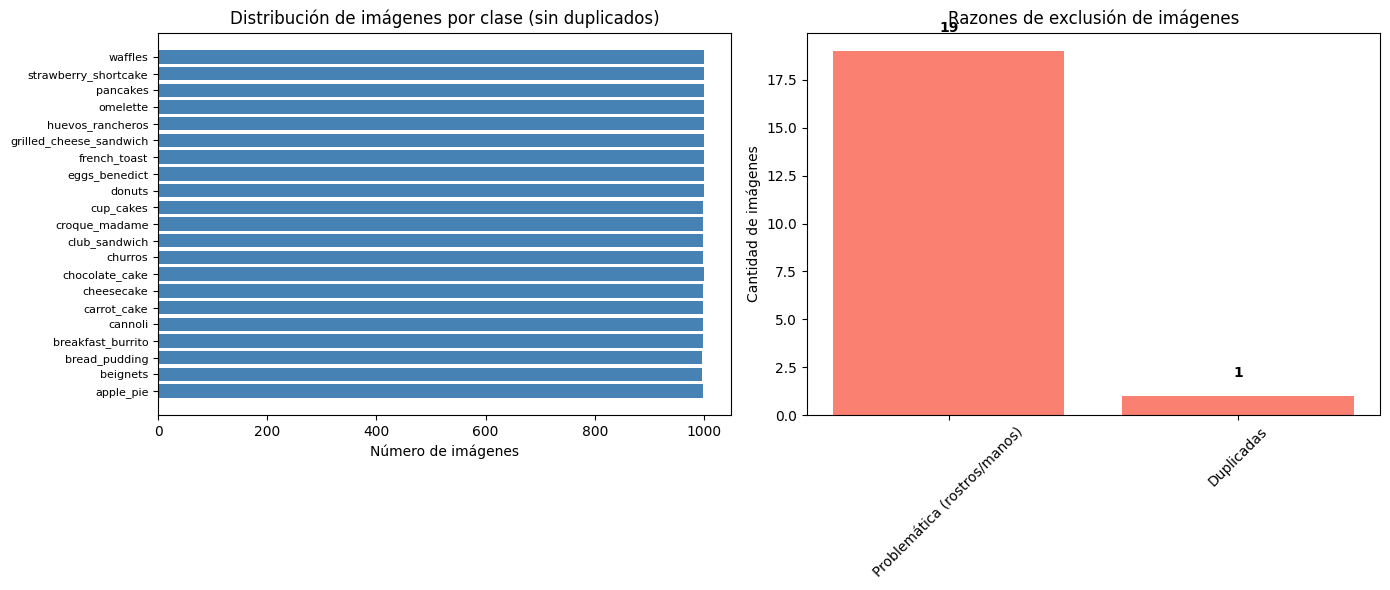

In [11]:
# PARTE 8: ESTADÍSTICAS FINALES CON VISUALIZACIONES
print("\n[PASO 8] Estadísticas finales y visualizaciones (sin duplicados ni problemáticas)...")
print("-" * 80)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Clases de desayuno
classes = [
    'apple_pie', 'beignets', 'bread_pudding', 'breakfast_burrito',
    'cannoli', 'carrot_cake', 'cheesecake', 'chocolate_cake', 'churros', 'club_sandwich',
    'croque_madame', 'cup_cakes', 'donuts', 'eggs_benedict',
    'french_toast', 'grilled_cheese_sandwich', 'huevos_rancheros', 'omelette', 'pancakes',
    'strawberry_shortcake', 'waffles'
]

# Cargar estadísticas de Parte 7
stats_path = '/content/desayuno_preprocessed/stats.npy'
if not os.path.exists(stats_path):
    print("❌ stats.npy no encontrado")
    stats = {cls: {'processed': 0, 'skipped': 0, 'rejections': {}} for cls in classes}
else:
    stats = np.load(stats_path, allow_pickle=True).item()

# Calcular estadísticas finales
total_clases = len(classes)
total_imagenes = sum(stats[cls]['processed'] for cls in classes)
total_problematicas = sum(stats[cls]['skipped'] for cls in classes)
total_duplicadas = sum(len(duplicates_list.get(cls, [])) for cls in classes)

# Distribución de imágenes por clase
distribucion_clases = {cls: stats[cls]['processed'] for cls in classes}
clase_min_imagenes = min(distribucion_clases.values()) if total_imagenes > 0 else 0
clase_max_imagenes = max(distribucion_clases.values()) if total_imagenes > 0 else 0
clase_media_imagenes = np.mean(list(distribucion_clases.values())) if total_imagenes > 0 else 0

# Razones de exclusión
reasons = ['Problemática (rostros/manos)', 'Error lectura']
exclusion_counts = {}
for reason in reasons:
    exclusion_counts[reason] = sum(
        stats[cls]['rejections'].get(reason, 0) for cls in classes
    )
exclusion_counts['Duplicadas'] = total_duplicadas

# Estadísticas finales
final_stats = {
    'total_clases': total_clases,
    'total_imagenes': total_imagenes,
    'clase_min_imagenes': clase_min_imagenes,
    'clase_max_imagenes': clase_max_imagenes,
    'clase_media_imagenes': clase_media_imagenes,
    'imágenes_problemáticas': total_problematicas,
    'imágenes_duplicadas': total_duplicadas,
    'exclusiones_por_razón': exclusion_counts,
    'target_size': 48  # Como en Parte 7
}

# Imprimir resumen
print("\n📊 Resumen final:")
for key, value in final_stats.items():
    if key not in ['distribucion_clases', 'exclusiones_por_razón']:
        print(f"   {key}: {value}")

print(f"\n🏷️ Distribución de clases:")
for cls, count in distribucion_clases.items():
    if count > 0:
        print(f"   {cls}: {count} imágenes")
print(f"   Total: {total_clases} clases")

print(f"\n🚫 Exclusiones por razón:")
for reason, count in exclusion_counts.items():
    if count > 0:
        print(f"   {reason}: {count}")

# Visualizaciones
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Distribución de imágenes por clase
ax1 = axes[0]
cls_names = [cls for cls in classes if distribucion_clases[cls] > 0]
cls_counts = [distribucion_clases[cls] for cls in cls_names]
ax1.barh(cls_names, cls_counts, color='steelblue')
ax1.set_xlabel('Número de imágenes')
ax1.set_title('Distribución de imágenes por clase (sin duplicados)')
ax1.tick_params(axis='y', labelsize=8)

# 2. Razones de exclusión
ax2 = axes[1]
exclusion_labels = [reason for reason, count in exclusion_counts.items() if count > 0]
exclusion_values = [count for count in exclusion_counts.values() if count > 0]
ax2.bar(exclusion_labels, exclusion_values, color='salmon')
ax2.set_ylabel('Cantidad de imágenes')
ax2.set_title('Razones de exclusión de imágenes')
ax2.tick_params(axis='x', rotation=45)
for i, v in enumerate(exclusion_values):
    ax2.text(i, v + 1, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [12]:
import pickle
import os
import numpy as np
import pandas as pd
import shutil
from google.colab import files

# PARTE 9: GUARDAR DATASET PREPROCESADO (PKL)
print("\n[PASO 9] Guardando dataset preprocesado...")
print("-" * 80)

# Configuración para Colab
OUTPUT_DIR = '/content/desayuno_preprocessed'
os.makedirs(OUTPUT_DIR, exist_ok=True)
PKL_OUTPUT = os.path.join(OUTPUT_DIR, 'food101_desayuno_preprocessed.pkl')
SUMMARY_CSV = os.path.join(OUTPUT_DIR, 'dataset_desayuno_summary.csv')
ZIP_OUTPUT = '/content/desayuno_preprocessed_archive.zip'

# Clases de desayuno
classes = [
    'apple_pie', 'beignets', 'bread_pudding', 'breakfast_burrito',
    'cannoli', 'carrot_cake', 'cheesecake', 'chocolate_cake', 'churros', 'club_sandwich',
    'croque_madame', 'cup_cakes', 'donuts', 'eggs_benedict',
    'french_toast', 'grilled_cheese_sandwich', 'huevos_rancheros', 'omelette', 'pancakes',
    'strawberry_shortcake', 'waffles'
]

# Cargar estadísticas de Parte 7
stats_path = os.path.join(OUTPUT_DIR, 'stats.npy')
try:
    if not os.path.exists(stats_path):
        print("⚠️ stats.npy no encontrado, inicializando estadísticas vacías")
        stats = {cls: {'processed': 0, 'skipped': 0, 'rejections': {}} for cls in classes}
    else:
        stats = np.load(stats_path, allow_pickle=True).item()
        print("✅ stats.npy cargado correctamente")
except Exception as e:
    print(f"❌ Error al cargar {stats_path}: {e}")
    stats = {cls: {'processed': 0, 'skipped': 0, 'rejections': {}} for cls in classes}

# Listar archivos NPZ generados en Parte 7
try:
    npz_files = [f for f in os.listdir(OUTPUT_DIR) if f.endswith('.npz')]
    print(f"📂 Archivos .npz encontrados en {OUTPUT_DIR}: {len(npz_files)}")
    if not npz_files:
        print(f"❌ ERROR: No se encontraron archivos .npz en {OUTPUT_DIR}")
        print("💡 Verifica que la Parte 7 generó los archivos .npz correctamente")
        print("💡 Pasos para solucionar:")
        print("   1. Reejecuta la Parte 7 para generar los 1035 archivos .npz")
        print("   2. Asegúrate de que /content/images_clean contiene las imágenes")
        raise FileNotFoundError("No se encontraron archivos .npz")
    else:
        print(f"   Ejemplo de archivos .npz (primeros 5):")
        for npz_file in npz_files[:5]:
            print(f"     {npz_file}")
except Exception as e:
    print(f"❌ Error al listar archivos .npz en {OUTPUT_DIR}: {e}")
    raise

# Estadísticas finales
try:
    total_imagenes = sum(stats[cls]['processed'] for cls in classes)
    total_problematicas = sum(stats[cls]['skipped'] for cls in classes)
    try:
        total_duplicadas = sum(len(duplicates_list.get(cls, [])) for cls in classes)
    except NameError:
        print("⚠️ duplicates_list no definida, estableciendo imágenes duplicadas a 0")
        total_duplicadas = 0
    distribucion_clases = {cls: stats[cls]['processed'] for cls in classes}
except Exception as e:
    print(f"❌ Error al calcular estadísticas: {e}")
    total_duplicadas = 0
    distribucion_clases = {cls: stats[cls]['processed'] for cls in classes}

final_stats = {
    'total_clases': len(classes),
    'total_imagenes': total_imagenes,
    'imágenes_problemáticas': total_problematicas,
    'imágenes_duplicadas': total_duplicadas,
    'distribucion_clases': distribucion_clases,
    'target_size': 48
}

# Crear paquete de datos
dataset_package = {
    'npz_files': npz_files,
    'class_names': classes,
    'stats': final_stats
}

# Guardar en pickle
try:
    with open(PKL_OUTPUT, 'wb') as f:
        pickle.dump(dataset_package, f)
    print(f"✅ Dataset guardado en: {PKL_OUTPUT}")
    print(f"   Tamaño del archivo: {os.path.getsize(PKL_OUTPUT) / (1024**2):.2f} MB")
    print(f"   Archivos NPZ registrados: {len(npz_files)}")
except Exception as e:
    print(f"❌ Error al guardar {PKL_OUTPUT}: {e}")
    raise

# Guardar resumen CSV
try:
    summary_df = pd.DataFrame({
        'clase_nombre': classes,
        'num_imagenes': [distribucion_clases[cls] for cls in classes]
    })
    summary_df.to_csv(SUMMARY_CSV, index=False)
    print(f"✅ Resumen guardado en: {SUMMARY_CSV}")
except Exception as e:
    print(f"❌ Error al guardar {SUMMARY_CSV}: {e}")
    raise

# Comprimir el directorio para persistencia
try:
    shutil.make_archive('/content/desayuno_preprocessed_archive', 'zip', OUTPUT_DIR)
    print(f"✅ Archivos comprimidos en {ZIP_OUTPUT}")
except Exception as e:
    print(f"❌ Error al comprimir el directorio: {e}")
    raise

# Descargar el ZIP automáticamente a tu computadora
try:
    files.download(ZIP_OUTPUT)
    print("✅ Descargando desayuno_preprocessed_archive.zip a tu computadora")
except Exception as e:
    print(f"❌ Error al descargar el ZIP: {e}")
    print("💡 Ve al panel de archivos en Colab, busca /content/desayuno_preprocessed_archive.zip, haz clic derecho y selecciona 'Download'")


[PASO 9] Guardando dataset preprocesado...
--------------------------------------------------------------------------------
✅ stats.npy cargado correctamente
📂 Archivos .npz encontrados en /content/desayuno_preprocessed: 1039
   Ejemplo de archivos .npz (primeros 5):
     c002_batch0034.npz
     c013_batch0025.npz
     c004_batch0001.npz
     c005_batch0039.npz
     c015_batch0019.npz
✅ Dataset guardado en: /content/desayuno_preprocessed/food101_desayuno_preprocessed.pkl
   Tamaño del archivo: 0.02 MB
   Archivos NPZ registrados: 1039
✅ Resumen guardado en: /content/desayuno_preprocessed/dataset_desayuno_summary.csv
✅ Archivos comprimidos en /content/desayuno_preprocessed_archive.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Descargando desayuno_preprocessed_archive.zip a tu computadora


In [13]:
# PARTE 10: INSTRUCCIONES PARA CARGAR EL DATASET
print("\n[PASO 10] Instrucciones para usar el dataset...")
print("-" * 80)

import os

# Configuración
OUTPUT_DIR = '/content/desayuno_preprocessed'
PKL_PATH = os.path.join(OUTPUT_DIR, 'food101_desayuno_preprocessed.pkl')

# Código de ejemplo para cargar el dataset
load_code = """
# Para cargar el dataset preprocesado en otro notebook:

import pickle
import numpy as np
import os

# Ruta al archivo pickle
PKL_PATH = '/content/desayuno_preprocessed/food101_desayuno_preprocessed.pkl'

# Cargar el pickle
with open(PKL_PATH, 'rb') as f:
    data = pickle.load(f)

# Obtener componentes
npz_files = data['npz_files']  # Lista de archivos NPZ
class_names = data['class_names']  # Lista de nombres de clases
stats = data['stats']  # Estadísticas

# Cargar imágenes y etiquetas desde archivos NPZ
X = []  # Imágenes (lista de arrays)
y = []  # Etiquetas
for npz_file in npz_files:
    npz_path = os.path.join('/content/desayuno_preprocessed', npz_file)
    with np.load(npz_path) as npz:
        X.append(npz['X'])  # Arrays de imágenes (batch_size, 48, 48, 3)
        y.append(npz['y'])  # Arrays de etiquetas
X = np.concatenate(X, axis=0)  # Unir en un solo array (N, 48, 48, 3)
y = np.concatenate(y, axis=0)  # Unir en un solo array (N,)

print(f"Imágenes: {X.shape}")
print(f"Etiquetas: {y.shape}")
print(f"Clases: {len(class_names)}")
print(f"Estadísticas: {stats}")
"""

# Imprimir código
print(load_code)

# Guardar código de ejemplo
example_path = os.path.join(OUTPUT_DIR, 'load_dataset_example.py')
with open(example_path, 'w') as f:
    f.write(load_code)

print(f"✅ Código de ejemplo guardado en: {example_path}")


[PASO 10] Instrucciones para usar el dataset...
--------------------------------------------------------------------------------

# Para cargar el dataset preprocesado en otro notebook:

import pickle
import numpy as np
import os

# Ruta al archivo pickle
PKL_PATH = '/content/desayuno_preprocessed/food101_desayuno_preprocessed.pkl'

# Cargar el pickle
with open(PKL_PATH, 'rb') as f:
    data = pickle.load(f)

# Obtener componentes
npz_files = data['npz_files']  # Lista de archivos NPZ
class_names = data['class_names']  # Lista de nombres de clases
stats = data['stats']  # Estadísticas

# Cargar imágenes y etiquetas desde archivos NPZ
X = []  # Imágenes (lista de arrays)
y = []  # Etiquetas
for npz_file in npz_files:
    npz_path = os.path.join('/content/desayuno_preprocessed', npz_file)
    with np.load(npz_path) as npz:
        X.append(npz['X'])  # Arrays de imágenes (batch_size, 48, 48, 3)
        y.append(npz['y'])  # Arrays de etiquetas
X = np.concatenate(X, axis=0)  # Unir en un

In [14]:
# PARTE 11: RESUMEN FINAL
print("\n" + "=" * 80)
print("✅ EDA COMPLETADO EXITOSAMENTE")
print("=" * 80)

import os
import numpy as np

# Configuración
OUTPUT_DIR = '/content/desayuno_preprocessed'

# Cargar estadísticas de Parte 7
stats_path = os.path.join(OUTPUT_DIR, 'stats.npy')
if not os.path.exists(stats_path):
    print("❌ stats.npy no encontrado")
    stats = {cls: {'processed': 0, 'skipped': 0, 'rejections': {}} for cls in [
        'apple_pie', 'beignets', 'bread_pudding', 'breakfast_burrito',
        'cannoli', 'carrot_cake', 'cheesecake', 'chocolate_cake', 'churros', 'club_sandwich',
        'croque_madame', 'cup_cakes', 'donuts', 'eggs_benedict',
        'french_toast', 'grilled_cheese_sandwich', 'huevos_rancheros', 'omelette', 'pancakes',
        'strawberry_shortcake', 'waffles'
    ]}
else:
    stats = np.load(stats_path, allow_pickle=True).item()

# Calcular estadísticas
total_imagenes = sum(stats[cls]['processed'] for cls in stats)
total_problematicas = sum(stats[cls]['skipped'] for cls in stats)
total_duplicadas = sum(len(duplicates_list.get(cls, [])) for cls in stats)
counts = [stats[cls]['processed'] for cls in stats]
total_clases = len([cls for cls in stats if stats[cls]['processed'] > 0])
min_imagenes = min(counts) if total_imagenes > 0 else 0
max_imagenes = max(counts) if total_imagenes > 0 else 0
mean_imagenes = np.mean(counts) if total_imagenes > 0 else 0

# Listar archivos generados
print(f"\n📦 Archivos generados en {OUTPUT_DIR}:")
print(f"   ✅ food101_desayuno_preprocessed.pkl - Dataset preprocesado (referencias a NPZ)")
print(f"   ✅ dataset_desayuno_summary.csv - Resumen por clase")
print(f"   ✅ load_dataset_example.py - Código para cargar el dataset")
print(f"   ✅ *.npz - Imágenes preprocesadas ({len([f for f in os.listdir(OUTPUT_DIR) if f.endswith('.npz')])} archivos)")

# Imprimir estadísticas
print(f"\n📊 Dataset Stats:")
print(f"   • Total de imágenes: {total_imagenes:,}")
print(f"   • Total de clases: {total_clases}")
print(f"   • Dimensión imágenes: 48x48x3")
print(f"   • Rango valores: [0.000, 1.000] (normalizado)")
print(f"   • Imágenes por clase: {min_imagenes} - {max_imagenes} ({mean_imagenes:.0f} media)")
print(f"   • Imágenes problemáticas detectadas: {total_problematicas}")
print(f"   • Imágenes duplicadas eliminadas: {total_duplicadas}")

# Próximos pasos
print("\n🚀 Próximos pasos:")
print("   1. Usar load_dataset_example.py para cargar el dataset")
print("   2. Dividir en train/val/test (ejemplo: 70%/15%/15%)")
print("   3. Entrenar modelos (ejemplo: CNN simple o ResNet50)")
print("   4. Evaluar métricas (precisión, F1-score)")

print("\n" + "=" * 80 + "\n")


✅ EDA COMPLETADO EXITOSAMENTE

📦 Archivos generados en /content/desayuno_preprocessed:
   ✅ food101_desayuno_preprocessed.pkl - Dataset preprocesado (referencias a NPZ)
   ✅ dataset_desayuno_summary.csv - Resumen por clase
   ✅ load_dataset_example.py - Código para cargar el dataset
   ✅ *.npz - Imágenes preprocesadas (1039 archivos)

📊 Dataset Stats:
   • Total de imágenes: 20,980
   • Total de clases: 21
   • Dimensión imágenes: 48x48x3
   • Rango valores: [0.000, 1.000] (normalizado)
   • Imágenes por clase: 996 - 1000 (999 media)
   • Imágenes problemáticas detectadas: 19
   • Imágenes duplicadas eliminadas: 1

🚀 Próximos pasos:
   1. Usar load_dataset_example.py para cargar el dataset
   2. Dividir en train/val/test (ejemplo: 70%/15%/15%)
   3. Entrenar modelos (ejemplo: CNN simple o ResNet50)
   4. Evaluar métricas (precisión, F1-score)


